In [430]:
import pandas as pd

In [431]:
df = pd.read_csv("hvac_sensor_data.csv")


In [432]:
df['airflow']

0      323.238443
1      323.837174
2      311.375411
3             NaN
4      316.996807
          ...    
995    324.101492
996    321.400227
997    315.910541
998    318.597490
999    326.730499
Name: airflow, Length: 1000, dtype: float64

In [433]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  1000 non-null   object 
 1   unit_id    1000 non-null   object 
 2   temp       863 non-null    float64
 3   pressure   1000 non-null   float64
 4   airflow    853 non-null    float64
 5   vibration  1000 non-null   float64
 6   power      1000 non-null   float64
dtypes: float64(5), object(2)
memory usage: 54.8+ KB


In [434]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df = df.sort_values(['unit_id', 'timestamp'])

df.head()

,timestamp,unit_id,temp,pressure,airflow,vibration,power
0,2026-01-01 00:00:00,HVAC_1,NaN,1.193087,323.238443,0.027615,4.953169
1,2026-01-01 00:05:00,HVAC_1,21.929759,1.278961,323.837174,0.017653,5.108512
2,2026-01-01 00:10:00,HVAC_1,22.072589,1.104336,311.375411,0.017189,4.797434
3,2026-01-01 00:15:00,HVAC_1,22.094274,1.273282,NaN,0.020338,4.715050
4,2026-01-01 00:20:00,HVAC_1,21.654702,1.218785,316.996807,0.018542,4.879659


In [435]:
sensor_cols = ['temp', 'pressure', 'airflow', 'vibration', 'power']

# Step 1: Interpolation
df[sensor_cols] = df.groupby('unit_id')[sensor_cols].transform(
    lambda x: x.interpolate(method='linear')
)

# Step 2: Forward fill
df[sensor_cols] = df.groupby('unit_id')[sensor_cols].transform(
    lambda x: x.ffill()
)

# Step 3: Feature-based (example)
df['temp_pressure_ratio'] = df['temp'] / (df['pressure'] + 1e-5)

df['temp'] = df['temp'].fillna(
    df['pressure'] * df.groupby('unit_id')['temp_pressure_ratio'].transform(lambda x: x.rolling(5, min_periods=1).mean())
)

# Step 4: Final fallback
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

In [436]:
df

,timestamp,unit_id,temp,pressure,airflow,vibration,power,temp_pressure_ratio
0,2026-01-01 00:00:00,HVAC_1,21.999208,1.193087,323.238443,0.027615,4.953169,NaN
1,2026-01-01 00:05:00,HVAC_1,21.929759,1.278961,323.837174,0.017653,5.108512,17.146413
2,2026-01-01 00:10:00,HVAC_1,22.072589,1.104336,311.375411,0.017189,4.797434,19.987023
3,2026-01-01 00:15:00,HVAC_1,22.094274,1.273282,314.186109,0.020338,4.715050,17.352082
4,2026-01-01 00:20:00,HVAC_1,21.654702,1.218785,316.996807,0.018542,4.879659,17.767306
...,...,...,...,...,...,...,...,...
995,2026-01-01 16:15:00,HVAC_5,21.914389,1.165716,324.101492,0.015245,5.139186,18.798915
996,2026-01-01 16:20:00,HVAC_5,21.930571,1.148837,321.400227,0.006627,4.649805,19.089195
997,2026-01-01 16:25:00,HVAC_5,21.946752,1.121028,315.910541,0.021956,5.116356,19.577168
998,2026-01-01 16:30:00,HVAC_5,22.119219,1.162627,318.597490,0.012986,4.978372,19.025040


In [437]:
df.isnull().sum()

timestamp              0
unit_id                0
temp                   0
pressure               0
airflow                0
vibration              0
power                  0
temp_pressure_ratio    1
dtype: int64

In [438]:
df.isnull().values.any()

np.True_

In [439]:
df['temp_mean_5'] = df.groupby('unit_id')['temp'].transform(lambda x: x.rolling(5, min_periods=1).mean())
df['pressure_mean_5'] = df.groupby('unit_id')['pressure'].transform(lambda x: x.rolling(5, min_periods=1).mean())
df['vibration_mean_5'] = df.groupby('unit_id')['vibration'].transform(lambda x: x.rolling(5, min_periods=1).mean())

In [440]:
df['temp_delta'] = df['temp'] - df['temp_mean_5']
df['pressure_delta'] = df['pressure'] - df['pressure_mean_5']
df['vibration_delta'] = df['vibration'] - df['vibration_mean_5']

In [441]:
df['temp_rate'] = df.groupby('unit_id')['temp'].diff()
df['pressure_rate'] = df.groupby('unit_id')['pressure'].diff()
df['vibration_rate'] = df.groupby('unit_id')['vibration'].diff()

In [442]:
df['pressure_drop'] = df.groupby('unit_id')['pressure'].pct_change()
df['airflow_drop'] = df.groupby('unit_id')['airflow'].pct_change()
df['vibration_spike'] = df.groupby('unit_id')['vibration'].pct_change()

In [443]:
df['temp_airflow_ratio'] = df['temp'] / (df['airflow'] + 1e-5)
df['temp_pressure_ratio'] = df['temp'] / (df['pressure'] + 1e-5)

In [444]:
df.head()

,timestamp,unit_id,temp,pressure,airflow,vibration,power,temp_pressure_ratio,temp_mean_5,pressure_mean_5,...,temp_delta,pressure_delta,vibration_delta,temp_rate,pressure_rate,vibration_rate,pressure_drop,airflow_drop,vibration_spike,temp_airflow_ratio
0,2026-01-01 00:00:00,HVAC_1,21.999208,1.193087,323.238443,0.027615,4.953169,18.438746,21.999208,1.193087,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.068059
1,2026-01-01 00:05:00,HVAC_1,21.929759,1.278961,323.837174,0.017653,5.108512,17.146413,21.964484,1.236024,...,-0.034725,0.042937,-0.004981,-0.069449,0.085874,-0.009963,0.071976,0.001852,-0.360763,0.067718
2,2026-01-01 00:10:00,HVAC_1,22.072589,1.104336,311.375411,0.017189,4.797434,19.987023,22.000519,1.192128,...,0.072070,-0.087792,-0.003630,0.142830,-0.174625,-0.000464,-0.136536,-0.038482,-0.026289,0.070887
3,2026-01-01 00:15:00,HVAC_1,22.094274,1.273282,314.186109,0.020338,4.715050,17.352082,22.023957,1.212416,...,0.070317,0.060866,-0.000361,0.021686,0.168946,0.003149,0.152985,0.009027,0.183208,0.070322
4,2026-01-01 00:20:00,HVAC_1,21.654702,1.218785,316.996807,0.018542,4.879659,17.767306,21.950106,1.213690,...,-0.295404,0.005095,-0.001726,-0.439572,-0.054498,-0.001796,-0.042801,0.008946,-0.088315,0.068312


In [445]:
df.columns

Index(['timestamp', 'unit_id', 'temp', 'pressure', 'airflow', 'vibration',
       'power', 'temp_pressure_ratio', 'temp_mean_5', 'pressure_mean_5',
       'vibration_mean_5', 'temp_delta', 'pressure_delta', 'vibration_delta',
       'temp_rate', 'pressure_rate', 'vibration_rate', 'pressure_drop',
       'airflow_drop', 'vibration_spike', 'temp_airflow_ratio'],
      dtype='object')

In [446]:
df[['temp_delta', 'pressure_drop', 'vibration_spike']].describe()

,temp_delta,pressure_drop,vibration_spike
count,1000.000000,995.000000,995.000000
mean,0.008849,0.001268,0.098209
std,0.560227,0.060686,0.645219
min,-5.975451,-0.166072,-0.966564
25%,-0.161155,-0.040915,-0.193735
50%,0.015161,0.001106,0.002915
75%,0.184018,0.041906,0.232646
max,10.529832,0.187658,12.873040


In [447]:
# define features FIRST
feature_cols = [
    'temp', 'pressure', 'airflow', 'vibration', 'power',
    'temp_delta', 'pressure_delta', 'vibration_delta',
    'temp_rate', 'pressure_rate', 'vibration_rate',
    'pressure_drop', 'airflow_drop', 'vibration_spike',
    'temp_airflow_ratio', 'temp_pressure_ratio'
]

# THEN fill
df[feature_cols] = df[feature_cols].fillna(0)
import numpy as np
df.replace([np.inf, -np.inf], 0, inplace=True)

In [448]:
from sklearn.ensemble import IsolationForest

models = {}
df['anomaly_score'] = 0.0

for unit in df['unit_id'].unique():
    unit_data = df[df['unit_id'] == unit].copy()
    
    X = unit_data[feature_cols]
    
    model = IsolationForest(contamination=0.05, random_state=42)
    model.fit(X)
    
    scores = model.decision_function(X)
    
    df.loc[unit_data.index, 'anomaly_score'] = (scores.max() - scores)
    
    models[unit] = model
df['anomaly_score'] = df.groupby('unit_id')['anomaly_score'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

In [449]:
df[['unit_id', 'anomaly_score']].head(10)

,unit_id,anomaly_score
0,HVAC_1,0.005600
1,HVAC_1,0.256826
2,HVAC_1,0.531477
3,HVAC_1,0.375018
4,HVAC_1,0.074696
5,HVAC_1,0.185666
6,HVAC_1,0.042040
7,HVAC_1,0.054084
8,HVAC_1,0.210498
9,HVAC_1,0.179083


<Axes: xlabel='timestamp'>

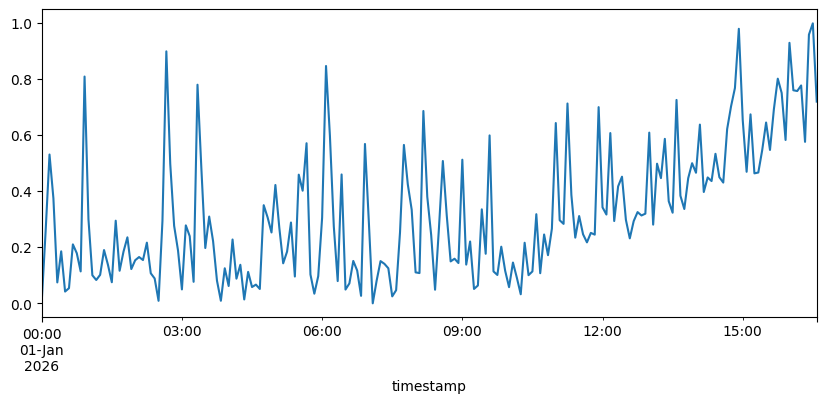

In [450]:
df[df['unit_id'] == 'HVAC_1'].set_index('timestamp')['anomaly_score'].plot(figsize=(10,4))

In [451]:
df['anomaly_score_smooth'] = df.groupby('unit_id')['anomaly_score'] \
    .transform(lambda x: x.rolling(5, min_periods=1).mean())

<Axes: xlabel='timestamp'>

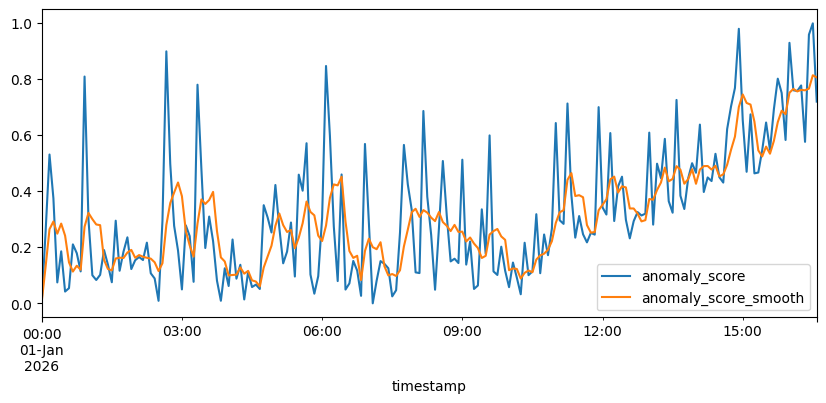

In [452]:
df[df['unit_id'] == 'HVAC_1'] \
  .set_index('timestamp')[['anomaly_score', 'anomaly_score_smooth']] \
  .plot(figsize=(10,4))

In [453]:
df['anomaly_trend'] = df.groupby('unit_id')['anomaly_score_smooth'].diff().fillna(0)

In [454]:
def get_alert(row):
    if row['anomaly_score_smooth'] > 0.6:
        return "CRITICAL"
    elif row['anomaly_score_smooth'] > 0.45 and row['anomaly_trend'] > 0:
        return "HIGH"
    elif row['anomaly_score_smooth'] > 0.3:
        return "MEDIUM"
    else:
        return "LOW"

In [455]:
df['alert_level'] = df.apply(get_alert, axis=1)

In [456]:
df[df['unit_id'] == 'HVAC_1'][['timestamp', 'anomaly_score_smooth', 'anomaly_trend', 'alert_level']].tail(20)

,timestamp,anomaly_score_smooth,anomaly_trend,alert_level
180,2026-01-01 15:00:00,0.746028,0.044738,CRITICAL
181,2026-01-01 15:05:00,0.715522,-0.030506,CRITICAL
182,2026-01-01 15:10:00,0.709814,-0.005708,CRITICAL
183,2026-01-01 15:15:00,0.648832,-0.060982,CRITICAL
184,2026-01-01 15:20:00,0.546172,-0.102660,MEDIUM
185,2026-01-01 15:25:00,0.524588,-0.021583,MEDIUM
186,2026-01-01 15:30:00,0.559772,0.035183,HIGH
187,2026-01-01 15:35:00,0.534353,-0.025418,MEDIUM
188,2026-01-01 15:40:00,0.580161,0.045807,HIGH
189,2026-01-01 15:45:00,0.647200,0.067039,CRITICAL


In [457]:
temp_thresh = df['temp_delta'].abs().quantile(0.9)
pressure_thresh = df['pressure_drop'].quantile(0.1)
vibration_thresh = df['vibration_spike'].quantile(0.9)

In [458]:
def explain_alert(row):
    reasons = []
    
    if abs(row['temp_delta']) > temp_thresh:
        reasons.append("Temperature deviation")
        
    if row['pressure_drop'] < pressure_thresh:
        reasons.append("Pressure drop")
        
    if row['vibration_spike'] > vibration_thresh:
        reasons.append("Vibration spike")
    
    if row['anomaly_trend'] > 0.02:
        reasons.append("Anomaly increasing")
    
    if row['anomaly_score_smooth'] > 0.35:
        reasons.append("Sustained abnormal behavior")
    
    if not reasons:
        if row['alert_level'] == "LOW":
            return "Normal system behavior"
        elif row['anomaly_score_smooth'] > 0.3:
            return "Unusual behavior detected (low signal confidence)"
        else:
            return "Minor deviation observed"
    
    return ", ".join(reasons[:2])

In [459]:
df['alert_reason'] = df.apply(explain_alert, axis=1)

In [460]:
def get_action(reason):
    if "Pressure drop" in reason:
        return "Check for leaks or blockage"
    elif "Vibration spike" in reason:
        return "Inspect motor/compressor"
    elif "Temperature deviation" in reason:
        return "Check cooling system"
    elif "Sustained abnormal behavior" in reason:
        return "Perform full system inspection"
    elif "Anomaly increasing" in reason:
        return "Monitor closely for escalation"
    else:
        return "Monitor system"

In [461]:
df['recommended_action'] = df['alert_reason'].apply(get_action)

In [462]:
df[['alert_reason', 'recommended_action']].head(10)


,alert_reason,recommended_action
0,Normal system behavior,Monitor system
1,Anomaly increasing,Monitor closely for escalation
2,"Pressure drop, Anomaly increasing",Check for leaks or blockage
3,Anomaly increasing,Monitor closely for escalation
4,Normal system behavior,Monitor system
5,"Temperature deviation, Anomaly increasing",Check cooling system
6,Normal system behavior,Monitor system
7,Normal system behavior,Monitor system
8,Normal system behavior,Monitor system
9,Anomaly increasing,Monitor closely for escalation


In [463]:
def format_alert(row):
    return {
        "unit_id": row['unit_id'],
        "timestamp": row['timestamp'].isoformat(),
        "alert_level": row['alert_level'],
        "confidence": round(min(1.0, row['anomaly_score_smooth'] * 1.2), 2),
        "reason": row['alert_reason'],
        "action": row['recommended_action']
    }

In [464]:
priority_map = {"CRITICAL": 3, "HIGH": 2, "MEDIUM": 1, "LOW": 0}
df['priority_score'] = df['alert_level'].map(priority_map)

In [465]:

df['alert_change'] = df.groupby('unit_id')['alert_level'].shift(1)
alerts = df[
    (df['alert_level'] != "LOW") &
    (df['alert_level'] != df['alert_change']) &   # 🔥 cooldown logic
    (df['anomaly_score_smooth'] > 0.35)
].sort_values(
    ['priority_score', 'anomaly_score_smooth', 'timestamp'],
    ascending=[False, False, False]
).head(10).apply(format_alert, axis=1).tolist()


In [466]:
print(alerts)

[{'unit_id': 'HVAC_1', 'timestamp': '2026-01-01T14:55:00', 'alert_level': 'CRITICAL', 'confidence': 0.84, 'reason': 'Temperature deviation, Anomaly increasing', 'action': 'Check cooling system'}, {'unit_id': 'HVAC_2', 'timestamp': '2026-01-01T04:25:00', 'alert_level': 'CRITICAL', 'confidence': 0.8, 'reason': 'Temperature deviation, Pressure drop', 'action': 'Check for leaks or blockage'}, {'unit_id': 'HVAC_1', 'timestamp': '2026-01-01T15:45:00', 'alert_level': 'CRITICAL', 'confidence': 0.78, 'reason': 'Anomaly increasing, Sustained abnormal behavior', 'action': 'Perform full system inspection'}, {'unit_id': 'HVAC_3', 'timestamp': '2026-01-01T12:10:00', 'alert_level': 'CRITICAL', 'confidence': 0.72, 'reason': 'Pressure drop, Anomaly increasing', 'action': 'Check for leaks or blockage'}, {'unit_id': 'HVAC_3', 'timestamp': '2026-01-01T15:55:00', 'alert_level': 'CRITICAL', 'confidence': 0.72, 'reason': 'Anomaly increasing, Sustained abnormal behavior', 'action': 'Perform full system inspec

In [467]:
alert_summary = df[df['alert_level'] != "LOW"].groupby('unit_id')['alert_level'].value_counts()
print(alert_summary)

unit_id  alert_level
HVAC_1   MEDIUM          55
         CRITICAL        16
         HIGH            16
HVAC_2   MEDIUM           7
         CRITICAL         2
         HIGH             2
HVAC_3   MEDIUM         104
         HIGH            24
         CRITICAL        10
HVAC_4   MEDIUM          74
         HIGH            11
HVAC_5   MEDIUM          64
         HIGH            10
Name: count, dtype: int64


In [468]:
# sanity checks
assert not df[feature_cols].isnull().any().any()
assert not np.isinf(df[feature_cols].values).any()

print(df['alert_level'].value_counts())

alert_level
LOW         605
MEDIUM      304
HIGH         63
CRITICAL     28
Name: count, dtype: int64


In [469]:
print(len(alerts))
print(alerts[:2])

10
[{'unit_id': 'HVAC_1', 'timestamp': '2026-01-01T14:55:00', 'alert_level': 'CRITICAL', 'confidence': 0.84, 'reason': 'Temperature deviation, Anomaly increasing', 'action': 'Check cooling system'}, {'unit_id': 'HVAC_2', 'timestamp': '2026-01-01T04:25:00', 'alert_level': 'CRITICAL', 'confidence': 0.8, 'reason': 'Temperature deviation, Pressure drop', 'action': 'Check for leaks or blockage'}]


In [471]:
print(df['alert_level'].value_counts())

alert_level
LOW         605
MEDIUM      304
HIGH         63
CRITICAL     28
Name: count, dtype: int64
